In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style("whitegrid")

# Load and prep (same as Day 1)
df = pd.read_csv('tetouancity.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.set_index('DateTime').sort_index()

# Rename columns for convenience
df.columns = ['zone1', 'zone2', 'zone3', 'temp', 'humidity', 'wind_speed', 'general_diffuse', 'diffuse']

print("✅ Data loaded:", df.shape)
df.head()

✅ Data loaded: (52416, 8)


,zone1,zone2,zone3,temp,humidity,wind_speed,general_diffuse,diffuse
DateTime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [3]:
print("Missing values BEFORE:")
print(df.isnull().sum())

# Time-series safe: interpolate then forward/back fill edges
df = df.interpolate(method='time')
df = df.fillna(method='ffill').fillna(method='bfill')

print("\nMissing values AFTER:")
print(df.isnull().sum())
print("\n✅ No missing values remaining!")

Missing values BEFORE:
zone1              0
zone2              0
zone3              0
temp               0
humidity           0
wind_speed         0
general_diffuse    0
diffuse            0
dtype: int64

Missing values AFTER:
zone1              0
zone2              0
zone3              0
temp               0
humidity           0
wind_speed         0
general_diffuse    0
diffuse            0
dtype: int64

✅ No missing values remaining!


In [4]:
df['hour']        = df.index.hour
df['dayofweek']   = df.index.dayofweek   # 0 = Monday
df['month']       = df.index.month
df['is_weekend']  = (df['dayofweek'] >= 5).astype(int)
df['is_night']    = ((df['hour'] < 6) | (df['hour'] >= 22)).astype(int)

print("✅ Time features added:")
print(df[['hour', 'dayofweek', 'month', 'is_weekend', 'is_night']].head(10))

✅ Time features added:
                     hour  dayofweek  month  is_weekend  is_night
DateTime                                                         
2017-01-01 00:00:00     0          6      1           1         1
2017-01-01 00:10:00     0          6      1           1         1
2017-01-01 00:20:00     0          6      1           1         1
2017-01-01 00:30:00     0          6      1           1         1
2017-01-01 00:40:00     0          6      1           1         1
2017-01-01 00:50:00     0          6      1           1         1
2017-01-01 01:00:00     1          6      1           1         1
2017-01-01 01:10:00     1          6      1           1         1
2017-01-01 01:20:00     1          6      1           1         1
2017-01-01 01:30:00     1          6      1           1         1


In [5]:
# Using Zone 1 as primary signal (most complete)
# Window = 144 → 24 hours at 10-min intervals

for window in [12, 144, 288]:   # 2hr, 24hr, 48hr
    label = f'w{window}'
    df[f'z1_rolling_mean_{label}'] = df['zone1'].rolling(window, min_periods=1).mean()
    df[f'z1_rolling_std_{label}']  = df['zone1'].rolling(window, min_periods=1).std().fillna(0)
    df[f'z1_rolling_min_{label}']  = df['zone1'].rolling(window, min_periods=1).min()
    df[f'z1_rolling_max_{label}']  = df['zone1'].rolling(window, min_periods=1).max()

print("✅ Rolling features added (3 windows × 4 stats = 12 new columns)")

✅ Rolling features added (3 windows × 4 stats = 12 new columns)


In [6]:
# How fast is power changing? (key signal for sudden outages)
df['z1_diff_1']   = df['zone1'].diff(1)    # change vs 10 min ago
df['z1_diff_6']   = df['zone1'].diff(6)    # change vs 1 hr ago
df['z1_diff_144'] = df['zone1'].diff(144)  # change vs same time yesterday

# Lag features (what was consumption N steps ago)
df['z1_lag_1']   = df['zone1'].shift(1)
df['z1_lag_6']   = df['zone1'].shift(6)
df['z1_lag_144'] = df['zone1'].shift(144)

# Fill NaNs created by diff/shift
df = df.fillna(method='bfill')

print("✅ Rate-of-change and lag features added")
print(df[['zone1', 'z1_diff_1', 'z1_diff_6', 'z1_lag_1']].head(10))

✅ Rate-of-change and lag features added
                     zone1  z1_diff_1  z1_diff_6  z1_lag_1
DateTime                                                  
2017-01-01 00:00:00  6.559     -0.145     -0.918     6.559
2017-01-01 00:10:00  6.414     -0.145     -0.918     6.559
2017-01-01 00:20:00  6.313     -0.101     -0.918     6.414
2017-01-01 00:30:00  6.121     -0.192     -0.918     6.313
2017-01-01 00:40:00  5.921     -0.200     -0.918     6.121
2017-01-01 00:50:00  5.853     -0.068     -0.918     5.921
2017-01-01 01:00:00  5.641     -0.212     -0.918     5.853
2017-01-01 01:10:00  5.496     -0.145     -0.918     5.641
2017-01-01 01:20:00  5.678      0.182     -0.635     5.496
2017-01-01 01:30:00  5.491     -0.187     -0.630     5.678


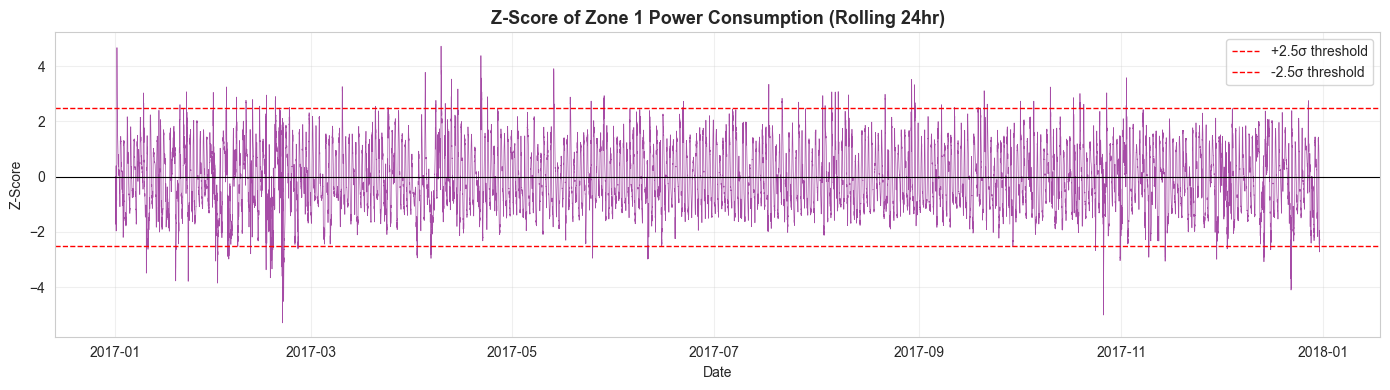

✅ Z-score feature added


In [7]:
rolling_mean_24h = df['zone1'].rolling(144, min_periods=1).mean()
rolling_std_24h  = df['zone1'].rolling(144, min_periods=1).std().fillna(1)

df['z1_zscore'] = (df['zone1'] - rolling_mean_24h) / rolling_std_24h

plt.figure(figsize=(14, 4))
plt.plot(df.index, df['z1_zscore'], color='purple', linewidth=0.5, alpha=0.7)
plt.axhline(y=2.5,  color='red',    linestyle='--', linewidth=1, label='+2.5σ threshold')
plt.axhline(y=-2.5, color='red',    linestyle='--', linewidth=1, label='-2.5σ threshold')
plt.axhline(y=0,    color='black',  linestyle='-',  linewidth=0.8)
plt.title('Z-Score of Zone 1 Power Consumption (Rolling 24hr)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Z-Score')
plt.legend()
plt.tight_layout()
plt.savefig('plot6_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Z-score feature added")

In [8]:
# OUTAGE DEFINITION:
# A reading is labelled as outage (1) if:
#   - Zone 1 drops below 30% of its 24hr rolling mean   → sudden power drop
#   OR
#   - Z-score is below -2.5                              → statistically extreme low

threshold_pct  = 0.30   # 30% of rolling mean
threshold_z    = -2.5   # 2.5 standard deviations below

rolling_mean_24h = df['zone1'].rolling(144, min_periods=1).mean()

condition_pct  = df['zone1'] < (threshold_pct * rolling_mean_24h)
condition_z    = df['z1_zscore'] < threshold_z

df['outage'] = ((condition_pct) | (condition_z)).astype(int)

# Summary
total   = len(df)
outages = df['outage'].sum()
normal  = total - outages

print("=" * 40)
print("🏷️  OUTAGE LABEL SUMMARY")
print("=" * 40)
print(f"Total records  : {total:,}")
print(f"Normal (0)     : {normal:,}  ({normal/total*100:.2f}%)")
print(f"Outage (1)     : {outages:,}  ({outages/total*100:.2f}%)")
print(f"\nClass imbalance ratio: 1 outage per {int(normal/max(outages,1))} normal records")

🏷️  OUTAGE LABEL SUMMARY
Total records  : 52,416
Normal (0)     : 52,035  (99.27%)
Outage (1)     : 381  (0.73%)

Class imbalance ratio: 1 outage per 136 normal records


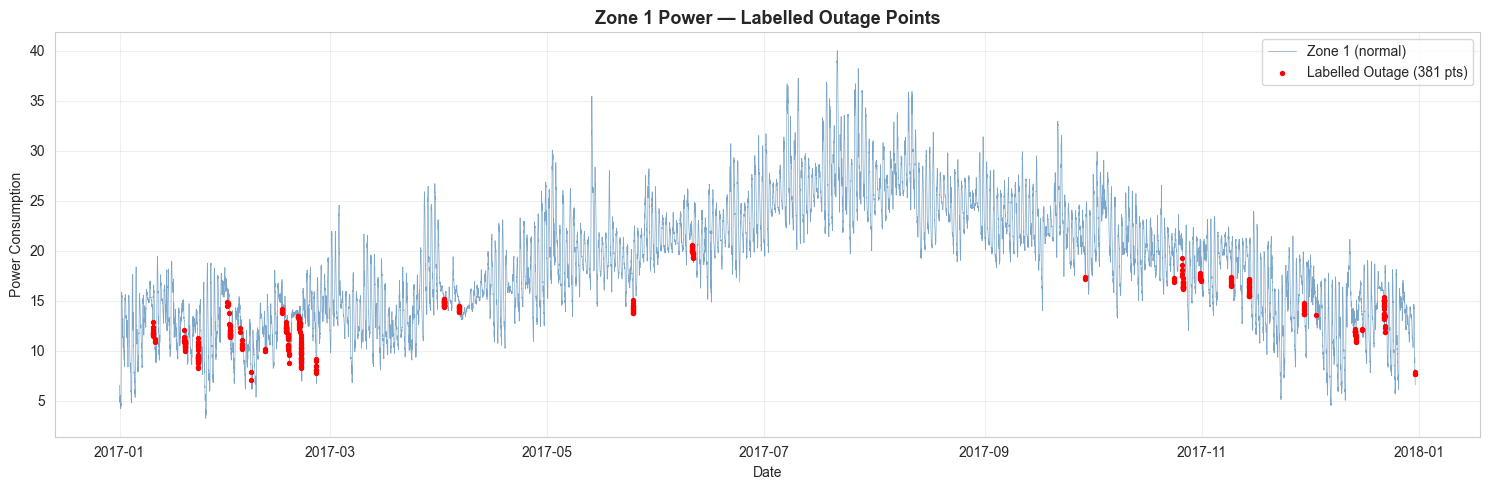

In [9]:
outage_points = df[df['outage'] == 1]

plt.figure(figsize=(15, 5))
plt.plot(df.index, df['zone1'], color='steelblue', linewidth=0.5, alpha=0.7, label='Zone 1 (normal)')
plt.scatter(outage_points.index, outage_points['zone1'],
            color='red', s=8, zorder=5, label=f'Labelled Outage ({len(outage_points):,} pts)')
plt.title('Zone 1 Power — Labelled Outage Points', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Power Consumption')
plt.legend()
plt.tight_layout()
plt.savefig('plot7_labelled_outages.png', dpi=150, bbox_inches='tight')
plt.show()

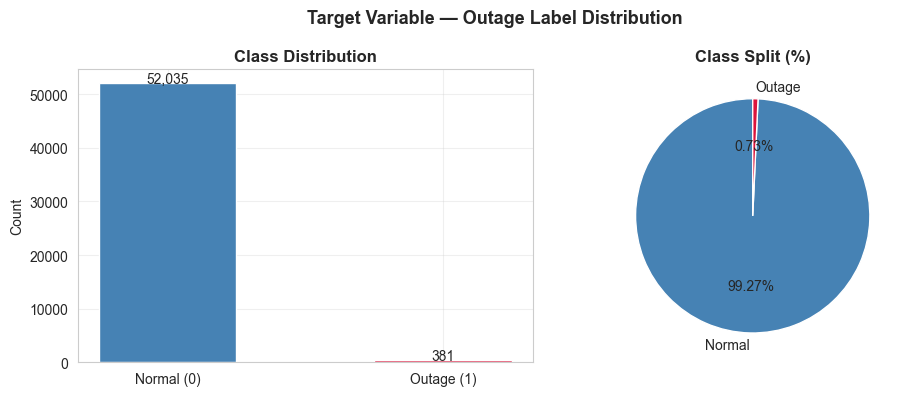

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
counts = df['outage'].value_counts()
axes[0].bar(['Normal (0)', 'Outage (1)'], counts.values,
            color=['steelblue', 'crimson'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=['Normal', 'Outage'],
            colors=['steelblue', 'crimson'], autopct='%1.2f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Split (%)', fontsize=12, fontweight='bold')

plt.suptitle('Target Variable — Outage Label Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot8_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Drop raw zone2/zone3 (we'll keep zone1 as main signal)
# Keep all engineered features + weather + time features
feature_cols = [
    'zone1', 'zone2', 'zone3',
    'temp', 'humidity', 'wind_speed',
    'hour', 'dayofweek', 'month', 'is_weekend', 'is_night',
    'z1_rolling_mean_w12',  'z1_rolling_std_w12',  'z1_rolling_min_w12',  'z1_rolling_max_w12',
    'z1_rolling_mean_w144', 'z1_rolling_std_w144', 'z1_rolling_min_w144', 'z1_rolling_max_w144',
    'z1_rolling_mean_w288', 'z1_rolling_std_w288', 'z1_rolling_min_w288', 'z1_rolling_max_w288',
    'z1_diff_1', 'z1_diff_6', 'z1_diff_144',
    'z1_lag_1',  'z1_lag_6',  'z1_lag_144',
    'z1_zscore'
]

X = df[feature_cols]
y = df['outage']

# Save for Day 3
df_final = X.copy()
df_final['outage'] = y
df_final.to_csv('features_day2.csv')

print("=" * 50)
print("📋 DAY 2 FEATURE ENGINEERING SUMMARY")
print("=" * 50)
print(f"Total features created : {len(feature_cols)}")
print(f"Feature matrix shape   : {X.shape}")
print(f"Target variable        : 'outage' (0 = normal, 1 = outage)")
print(f"Outage rate            : {y.mean()*100:.2f}%")
print(f"\nSaved → features_day2.csv ✅")
print("\n✅ Day 2 complete! Move on to Day 3 — Model Training.")

📋 DAY 2 FEATURE ENGINEERING SUMMARY
Total features created : 30
Feature matrix shape   : (52416, 30)
Target variable        : 'outage' (0 = normal, 1 = outage)
Outage rate            : 0.73%

Saved → features_day2.csv ✅

✅ Day 2 complete! Move on to Day 3 — Model Training.
